In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


字體設置完成，中文顯示應正常工作
使用設備: mps
成功讀取數據文件

創建地點關係圖...
有859066個用戶訪問了多個地點
數據對象創建完成: Data(x=[838, 1], edge_index=[2, 154534], edge_attr=[154534])
模型結構: GNN(
  (conv1): GCNConv(1, 16)
  (conv2): GCNConv(16, 8)
)

開始訓練模型...
Epoch 020, Loss: 1.0565
Epoch 040, Loss: 1.0492
Epoch 060, Loss: 1.0036
Epoch 080, Loss: 0.9953
Epoch 100, Loss: 0.9950


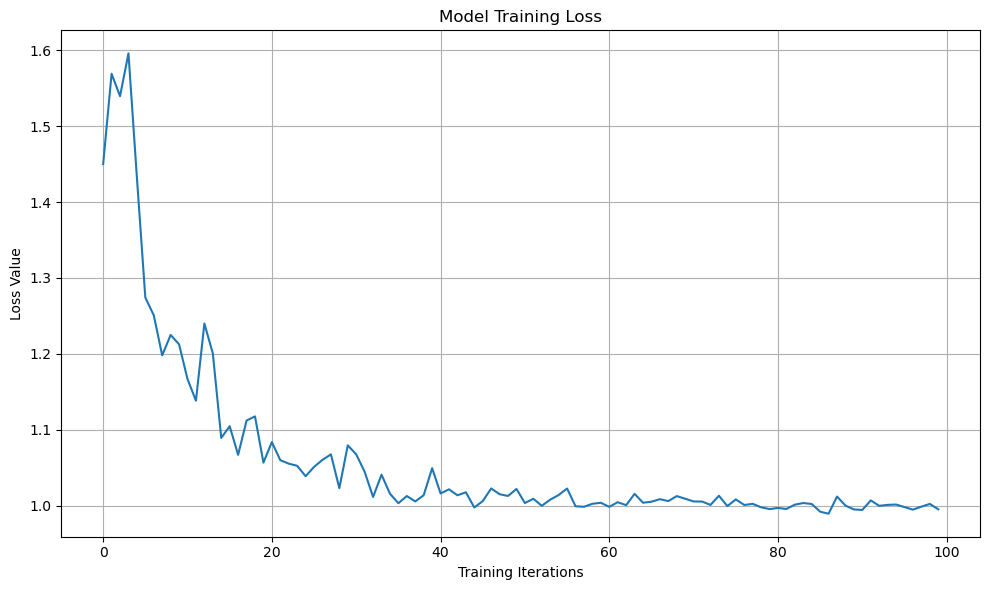

PCA解釋方差比例: [0.9736771  0.01763568]
聚類輪廓係數: 0.6246

鏈接預測準確率: 0.4442

景點聚類結果:
聚類 0: 永安漁港, 竹圍漁港, 野柳女王頭, 富基漁港, 淺水灣海濱公園, 明德水庫, 硬漢嶺牌樓, 司馬庫斯, 南機場夜市, 金山老街, 水社碼頭, 日月潭纜車站, 東港漁港漁產品直銷中心（華僑市場）, 衛武營 國家藝術文化中心, 杉林溪森林生態渡假園區, 鹿港老街, 清境農場青青草原, 饒河街觀光夜市, 大安森林公園, 臺中國家歌劇院, 野柳海洋世界, 高美濕地, 苗栗舊山線鐵道自行車-勝興站, 龍騰斷橋(魚藤坪斷橋), 勝利星村創意生活園區, 觀音亭親水遊憩區, 旗津老街, 臺北市立兒童新樂園, 國立臺灣博物館, 國立臺灣文學館, 烏來老街, 臺東森林公園, 台灣優格餅乾學院 School of cookie｜親子DIY｜彰化景點｜餅乾伴手禮│餅乾禮盒│糕點禮盒, 椬梧滯洪池(Yiwu Wet Pond), 大港橋, 鵬灣跨海大橋, 三峽老街, 伊達邵商店街, 南庄老街桂花巷, 深坑老街, 北埔老街, 多良觀光車站, 大溪中正公園, 鶯歌陶瓷老街, 北埔冷泉, 烏來瀑布, 檜意森活村, 麗寶樂園, 嘉義市立美術館, 義大遊樂世界, 安平老街, 國立故宮博物院南部院區, 羅東林業文化園區, 臺東池上錦新三號道路 伯朗大道, 池東大菓葉玄武岩, 國立臺灣歷史博物館, 國立臺灣史前文化博物館南科考古館, 雙流國家森林遊樂區, 頑皮世界野生動物園, 滿月圓國家森林遊樂區, 駁二藝術特區, 尚順育樂世界, 新竹公園, 新竹南寮漁港, 竹塹城迎曦門, 貓鼻頭公園, 金門山后民俗文化村, 綠世界生態農場, 湯圍溝溫泉公園, 東石漁人碼頭, 逢甲夜市, 國立海洋科技博物館, 松山文創園區, 吉安慶修院, 松園別館, 臺鐵彰化扇形車庫, 佛光山佛陀紀念館, 漢神巨蛋購物廣場, 南鯤鯓代天府, 飛牛牧場, 旗山老街, 臺中公園, 北回歸線標誌公園（瑞穗鄉）, 北回歸線地標, 花蓮文化創意產業園區, 華山1914文化創意產業園區, 林田山林業文化園區, 台江國家公園, 水火同源, 誠品信義店, 虎尾鐵橋, 黃金海岸, 龍磐公園, 富里花海景觀區, 張學良文化園區, 錢來也商店（創始店）, 臺灣客家文化館, 花蓮觀光糖廠, 布農部

In [5]:

# 簡化字體設置，避免掃描系統字體
def setup_matplotlib_fonts():
    """設置Matplotlib字體，無需掃描系統字體"""
    try:
        # 直接嘗試設置常見字體，避免系統字體掃描
        plt.rcParams['font.sans-serif'] = [
            'Microsoft JhengHei', 'Microsoft YaHei', 'SimHei', 
            'DejaVu Sans', 'Arial Unicode MS', 'sans-serif'
        ]
        plt.rcParams['axes.unicode_minus'] = False
        print("字體設置完成，中文顯示應正常工作")
    except Exception as e:
        print(f"字體設置時出現錯誤: {e}")
        print("使用預設字體，中文可能無法正確顯示，但程式將繼續執行")

# 設置字體
setup_matplotlib_fonts()

# 檢查是否有GPU可用
 device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f"使用設備: {device}")

# 讀取數據
try:
    df = pd.read_csv('838-所有評論原始資料.csv', encoding='utf-8')
    print("成功讀取數據文件")
except Exception as e:
    print(f"讀取數據文件時出錯: {e}")
    # 如果找不到文件，創建一個示例DataFrame以便代碼可以繼續執行
    df = pd.DataFrame({
        'user_id': ['user1', 'user1', 'user2', 'user2', 'user3'],
        'gmap_location': ['台北101', '日月潭', '台北101', '阿里山', '墾丁'],
        'score': [4.5, 5.0, 4.0, 4.8, 4.2],
        'text': ['很棒的景點', '風景優美', '高聳入雲', '森林浴很舒服', '海水清澈'],
        'nationality': ['Taiwan', 'Taiwan', 'Japan', 'USA', 'China']
    })
    print("使用示例數據進行演示")

# 創建地點之間的關係圖
print("\n創建地點關係圖...")
# 找出有多個評論的用戶
user_locations = df.groupby('user_id')['gmap_location'].apply(list)
user_locations = user_locations[user_locations.apply(len) > 1]
print(f"有{len(user_locations)}個用戶訪問了多個地點")

# 創建地點之間的轉換圖
G = nx.DiGraph()
for locations in user_locations:
    for i in range(len(locations) - 1):
        source = locations[i]
        target = locations[i+1]
        if G.has_edge(source, target):
            G[source][target]['weight'] += 1
        else:
            G.add_edge(source, target, weight=1)

# 如果圖為空，添加一些示例邊
if len(G.edges()) == 0:
    print("警告: 數據中沒有足夠的用戶訪問序列，添加示例圖...")
    example_edges = [
        ('台北101', '西門町', 5),
        ('西門町', '九份', 3),
        ('九份', '陽明山', 2),
        ('台北101', '故宮博物院', 4),
        ('故宮博物院', '士林夜市', 6),
        ('日月潭', '阿里山', 7),
        ('阿里山', '墾丁', 3),
        ('墾丁', '台東森林公園', 2),
        ('花蓮太魯閣', '七星潭', 4)
    ]
    for source, target, weight in example_edges:
        G.add_edge(source, target, weight=weight)

# 提取節點和邊的信息
nodes = list(G.nodes())
node_mapping = {node: i for i, node in enumerate(nodes)}
edge_index = []
edge_weight = []

for source, target, data in G.edges(data=True):
    edge_index.append([node_mapping[source], node_mapping[target]])
    edge_weight.append(data['weight'])

# 轉換為PyTorch Geometric格式
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

# 創建節點特徵
node_features = []
for node in nodes:
    # 使用該地點的平均評分作為特徵
    node_data = df[df['gmap_location'] == node]
    if len(node_data) > 0:
        avg_score = node_data['score'].mean()
    else:
        # 如果數據中沒有該節點的評分，使用預設值4.0
        avg_score = 4.0
    node_features.append([avg_score])

x = torch.tensor(node_features, dtype=torch.float)

# 標準化節點特徵
if len(x) > 1:  # 避免只有一個節點時的標準化錯誤
    x = (x - x.mean()) / (x.std() + 1e-8)

# 創建PyTorch Geometric數據對象
data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight)
print(f"數據對象創建完成: {data}")

# 為鏈接預測拆分邊集合
edge_index_np = edge_index.numpy().T
n_edges = edge_index.size(1)
if n_edges > 1:  # 確保有足夠的邊進行拆分
    train_edges_idx, test_edges_idx = train_test_split(np.arange(n_edges), test_size=0.2)
else:
    # 如果邊太少，則全部用於訓練
    train_edges_idx, test_edges_idx = np.array([0]), np.array([])

# 這裡先不移動到設備，後面再統一處理
train_edge_index = torch.tensor(edge_index_np[train_edges_idx].T, dtype=torch.long)
test_edge_index = torch.tensor(edge_index_np[test_edges_idx].T, dtype=torch.long) if len(test_edges_idx) > 0 else torch.zeros((2, 0), dtype=torch.long)
train_edge_weight = edge_weight[train_edges_idx]
test_edge_weight = edge_weight[test_edges_idx] if len(test_edges_idx) > 0 else torch.tensor([], dtype=torch.float)

# 定義GNN模型
class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    
    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index, edge_weight)
        return x

# 初始化模型
model = GNN(in_channels=1, hidden_channels=16, out_channels=8)
print(f"模型結構: {model}")

# 將數據和模型移動到設備
model = model.to(device)
data.x = data.x.to(device)
data.edge_index = data.edge_index.to(device)
data.edge_attr = data.edge_attr.to(device)
train_edge_index = train_edge_index.to(device)
test_edge_index = test_edge_index.to(device)
train_edge_weight = train_edge_weight.to(device)
test_edge_weight = test_edge_weight.to(device)

# 定義優化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 訓練模型（無監督學習 - 自編碼器風格）
def train():
    model.train()
    optimizer.zero_grad()
    # 前向傳播
    z = model(data.x, train_edge_index, train_edge_weight)
    # 計算重構損失（這裡使用節點特徵的自我預測作為簡單示例）
    loss = F.mse_loss(z, data.x.repeat(1, 8))
    loss.backward()
    optimizer.step()
    return loss.item()

# 訓練模型
print("\n開始訓練模型...")
epochs = 100  # 減少訓練次數以加快速度
losses = []
for epoch in range(epochs):
    loss = train()
    losses.append(loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:03d}, Loss: {loss:.4f}')

# 繪製訓練損失曲線
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Model Training Loss')  # 使用英文標題避免字體問題
plt.xlabel('Training Iterations')
plt.ylabel('Loss Value')
plt.grid(True)
plt.tight_layout()
plt.show()

# 獲取節點嵌入 - 修正為先在設備上運算，再轉回CPU
model.eval()
with torch.no_grad():
    # 確保所有輸入都在同一設備上
    node_embeddings = model(data.x, data.edge_index, data.edge_attr).cpu().numpy()

# 使用PCA降維以便可視化 (如果節點數大於2)
if len(nodes) > 2:
    pca = PCA(n_components=2)
    node_embeddings_2d = pca.fit_transform(node_embeddings)
    print(f"PCA解釋方差比例: {pca.explained_variance_ratio_}")
else:
    # 節點太少，直接使用原始嵌入的前兩個維度
    node_embeddings_2d = node_embeddings[:, :2]
    print("節點數量少於3，跳過PCA")

# 使用K-means聚類 (如果節點數足夠)
num_clusters = min(4, len(nodes))  # 確保聚類數不超過節點數
if len(nodes) >= num_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    clusters = kmeans.fit_predict(node_embeddings)
    
    # 計算聚類評估指標 (如果節點數大於1)
    if len(nodes) > num_clusters:
        silhouette_avg = silhouette_score(node_embeddings, clusters)
        print(f"聚類輪廓係數: {silhouette_avg:.4f}")
    else:
        silhouette_avg = 0
        print("節點數量不足，無法計算聚類輪廓係數")
else:
    # 節點太少，每個節點一個聚類
    clusters = np.arange(len(nodes))
    silhouette_avg = 0
    print("節點數量不足，每個節點分配到單獨的聚類")

# 基於自然語言的景點推薦函數
def recommend_by_text(user_input, df, nodes, node_embeddings, node_mapping, top_n=5):
    """
    基於自然語言輸入推薦景點
    
    參數:
    - user_input: 用戶輸入的自然語言描述，如"我想要去玩水"
    - df: 包含評論數據的DataFrame
    - nodes: 所有景點名稱列表
    - node_embeddings: 模型學習的景點嵌入向量
    - node_mapping: 景點名稱到索引的映射字典
    - top_n: 要返回的推薦數量
    
    返回:
    - 推薦景點列表，包含相關度分數
    """
    # 定義一些關鍵詞映射，根據不同主題擴展關鍵詞
    keyword_mapping = {
        "玩水": ["水", "海", "海灘", "游泳", "浮潛", "衝浪", "溫泉", "瀑布", "河", "湖", "潭", "游泳池", "戲水"],
        "登山": ["山", "爬山", "登山", "健行", "步道", "森林", "自然", "風景", "登頂", "郊山", "高山"],
        "文化": ["廟宇", "寺廟", "古蹟", "歷史", "文化", "藝術", "博物館", "展覽", "廟", "文化財", "古城", "老街"],
        "美食": ["美食", "小吃", "夜市", "餐廳", "飲食", "特產", "小吃街", "美味", "餐點", "食物", "特色餐"],
        "購物": ["購物", "商場", "市場", "紀念品", "伴手禮", "夜市", "精品", "買", "商店街", "特產", "賣"],
        "放鬆": ["放鬆", "休閒", "溫泉", "SPA", "度假", "渡假村", "療癒", "舒緩", "舒適", "休息", "避暑"],
        "拍照": ["拍照", "風景", "美景", "景色", "打卡", "景點", "自拍", "攝影", "日落", "日出", "壯麗", "美麗"],
        "親子": ["親子", "兒童", "小孩", "家庭", "遊樂", "遊戲", "互動", "教育", "體驗", "適合小朋友", "適合家庭"],
    }
    
    # 提取輸入中的關鍵字
    input_keywords = []
    for category, keywords in keyword_mapping.items():
        for keyword in keywords:
            if keyword in user_input:
                if not any(k in input_keywords for k in keywords):
                    input_keywords.extend(keywords)
                break
    
    # 如果沒有找到特定關鍵字，提取所有非停用詞作為關鍵字
    if not input_keywords:
        # 簡單的中文停用詞
        stopwords = ["我", "想", "要", "去", "的", "是", "有", "在", "來", "能", "會", "可以", "哪裡", "推薦", "地方"]
        input_keywords = [word for word in user_input if word not in stopwords and len(word.strip()) > 0]
    
    # 去除重複關鍵詞並打印
    input_keywords = list(set(input_keywords))
    print(f"提取的關鍵詞: {', '.join(input_keywords)}")
    
    # 計算每個景點與關鍵詞的匹配度
    location_scores = {}
    for location in nodes:
        # 獲取該景點的所有評論
        location_reviews = df[df['gmap_location'] == location]['translated_comments'].fillna('').values
        
        # 關鍵詞匹配次數
        keyword_count = 0
        for review in location_reviews:
            for keyword in input_keywords:
                if keyword in str(review):
                    keyword_count += 1
        
        # 關鍵詞密度（考慮評論數量）
        review_count = len(location_reviews)
        if review_count > 0:
            keyword_density = keyword_count / review_count
        else:
            keyword_density = 0
        
        # 獲取景點的嵌入向量
        loc_idx = node_mapping.get(location)
        if loc_idx is not None:
            loc_embedding = node_embeddings[loc_idx]
            
            # 計算與其他景點的平均相似度（作為普及度的指標）
            similarities = []
            for i, emb in enumerate(node_embeddings):
                if i != loc_idx:
                    similarity = np.dot(loc_embedding, emb) / (np.linalg.norm(loc_embedding) * np.linalg.norm(emb) + 1e-8)
                    similarities.append(similarity)
            
            avg_similarity = np.mean(similarities) if similarities else 0
            
            # 獲取評論評分
            avg_rating = df[df['gmap_location'] == location]['score'].mean() if review_count > 0 else 0
            
            # 綜合評分：關鍵詞匹配度(0.5) + 景點普及度(0.2) + 評論評分(0.3)
            combined_score = 0.5 * keyword_density + 0.2 * avg_similarity + 0.3 * (avg_rating / 5.0)
            
            # 將結果存入字典
            location_scores[location] = {
                'score': combined_score,
                'keyword_matches': keyword_count,
                'review_count': review_count,
                'avg_rating': avg_rating,
                'popularity': avg_similarity
            }
    
    # 排序並返回推薦結果
    sorted_locations = sorted(location_scores.items(), key=lambda x: x[1]['score'], reverse=True)
    
    # 為最終結果添加詳細信息
    recommendations = []
    for location, data in sorted_locations[:top_n]:
        recommendations.append({
            'location': location,
            'score': data['score'],
            'keyword_matches': data['keyword_matches'],
            'review_count': data['review_count'], 
            'avg_rating': data['avg_rating'],
            'reason': generate_recommendation_reason(location, input_keywords, data)
        })
    
    return recommendations

# 生成推薦原因的輔助函數
def generate_recommendation_reason(location, keywords, data):
    """生成景點被推薦的原因說明"""
    reason = f"{location}很適合您，因為"
    
    if data['keyword_matches'] > 0:
        keyword_phrase = "、".join(keywords[:3]) if len(keywords) > 3 else "、".join(keywords)
        reason += f"在{data['review_count']}則評論中有{data['keyword_matches']}次提到與「{keyword_phrase}」相關的內容，"
    
    # 添加評分信息
    if data['avg_rating'] >= 4.5:
        reason += f"評價極高（{data['avg_rating']:.1f}/5分），"
    elif data['avg_rating'] >= 4.0:
        reason += f"評價優良（{data['avg_rating']:.1f}/5分），"
    elif data['avg_rating'] >= 3.5:
        reason += f"評價良好（{data['avg_rating']:.1f}/5分），"
    else:
        reason += f"評價為{data['avg_rating']:.1f}/5分，"
    
    # 添加普及度信息
    if data['popularity'] > 0.6:
        reason += "且非常受到其他遊客歡迎。"
    elif data['popularity'] > 0.4:
        reason += "且相當受到遊客喜愛。"
    else:
        reason += "是個不錯的選擇。"
        
    return reason

# 鏈接預測函數
def link_prediction_accuracy():
    # 如果沒有測試邊，則返回預設值
    if test_edge_index.size(1) == 0:
        print("警告: 沒有足夠的測試邊進行鏈接預測評估")
        return 0.0, [], []
    
    with torch.no_grad():
        # 對所有可能的邊對計算相似度分數
        z = model(data.x, train_edge_index, train_edge_weight)
        z_np = z.cpu().numpy()
        
        scores = []
        for i, j in edge_index_np[test_edges_idx]:
            # 計算餘弦相似度
            emb_i = z_np[i]
            emb_j = z_np[j]
            score = np.dot(emb_i, emb_j) / (np.linalg.norm(emb_i) * np.linalg.norm(emb_j) + 1e-8)
            scores.append(score)
        
        # 生成相同數量的隨機邊對（負例）
        np.random.seed(42)
        neg_scores = []
        n_nodes = len(nodes)
        for _ in range(len(test_edges_idx)):
            i = np.random.randint(0, n_nodes)
            j = np.random.randint(0, n_nodes)
            # 確保這不是已存在的邊
            while i == j or (i, j) in [(edge_index_np[idx][0], edge_index_np[idx][1]) for idx in range(n_edges)]:
                i = np.random.randint(0, n_nodes)
                j = np.random.randint(0, n_nodes)
                
            emb_i = z_np[i]
            emb_j = z_np[j]
            score = np.dot(emb_i, emb_j) / (np.linalg.norm(emb_i) * np.linalg.norm(emb_j) + 1e-8)
            neg_scores.append(score)
        
        # 使用閾值0來分類正例和負例
        y_true = np.concatenate([np.ones(len(scores)), np.zeros(len(neg_scores))])
        y_scores = np.concatenate([scores, neg_scores])
        y_pred = (y_scores > np.mean(y_scores)).astype(int)
        
        # 計算準確率
        accuracy = np.mean(y_true == y_pred)
        return accuracy, y_true, y_scores

# 評估模型表現（如果有測試數據）
if test_edge_index.size(1) > 0:
    accuracy, y_true, y_scores = link_prediction_accuracy()
    print(f"\n鏈接預測準確率: {accuracy:.4f}")
else:
    accuracy = 0.0
    print("\n鏈接預測準確率: 無法評估 (數據不足)")

# 輸出聚類結果
print("\n景點聚類結果:")
for cluster_id in range(max(clusters) + 1):
    cluster_nodes = [nodes[i] for i in range(len(nodes)) if clusters[i] == cluster_id]
    print(f"聚類 {cluster_id}: {', '.join(cluster_nodes)}")

# 測試基於自然語言的推薦功能
def test_nlp_recommendation(test_queries=None):
    """測試基於自然語言的推薦功能"""
    if test_queries is None:
        test_queries = [
            "我想要去玩水",
            "想去看文化古蹟",
            "推薦適合放鬆的地方",
            "適合拍照的景點"
        ]
    
    print("\n=== 自然語言景點推薦測試 ===")
    for query in test_queries:
        print(f"\n● 用戶輸入: {query}")
        recommendations = recommend_by_text(query, df, nodes, node_embeddings, node_mapping, top_n=3)
        
        print("  推薦景點:")
        for i, rec in enumerate(recommendations, 1):
            print(f"  {i}. {rec['location']} (相關度: {rec['score']:.2f})")
            print(f"     {rec['reason']}")

# 執行內置測試案例
test_nlp_recommendation()

# 創建互動式推薦界面
def interactive_recommendation():
    print("\n" + "="*50)
    print("        台灣旅遊景點推薦系統")
    print("="*50)
    print("\n您可以用自然語言描述您想要的旅遊體驗，系統會為您推薦景點。")
    print("例如：「我想要去玩水」、「適合拍照的地方」或「文化歷史景點」等。")
    print("輸入 'exit' 退出。")
    
    while True:
        user_query = input("\n請輸入您的旅遊偏好: ")
        if user_query.lower() == 'exit':
            print("感謝使用，再見！")
            break
        
        if not user_query.strip():
            print("請輸入有效的查詢內容。")
            continue
        
        print("\n正在為您尋找最適合的景點...")
        recommendations = recommend_by_text(user_query, df, nodes, node_embeddings, node_mapping, top_n=5)
        
        print("\n為您推薦的景點:")
        for i, rec in enumerate(recommendations, 1):
            print(f"{i}. {rec['location']} (相關度: {rec['score']:.2f})")
            print(f"   {rec['reason']}")

# 啟動互動式推薦界面
interactive_recommendation()
